# LHC Collision Classification — Pipeline Walk-through

**Author:** Malek Elaghel  
**Course origin:** CSCI 450, Project 1 & Project 2 (significantly upgraded)

## Problem

Classify simulated 13 TeV proton-proton collision images into one of
three event types: QCD multi-jet background, top-antitop pair
production (TTbar), or W-boson + jets (WJets). The original course
work used HOG features + Random Forest / Linear SVM (Project 1) and a
set of CNN architectures (Project 2).

## What this notebook does

Because the full image dataset (~30k 372x1196 PNGs) is not bundled with
the repo, this notebook **demonstrates the rebuilt pipeline on a tiny
synthetic dataset** so it executes anywhere. The exact same code paths
are used in `src/train.py` for the real data; a one-line change to
`load_dataset(...)` plus a CLI flag is all that's needed.

1. Build a class-foldered synthetic dataset on disk.
2. Walk it with `data_loader.load_dataset()`.
3. Extract HOG features with `preprocessing.build_feature_matrix()`.
4. Run a 3-fold cross-validation across the model zoo
   (RF, Linear SVM, Gradient Boosting, XGBoost).
5. Plot the confusion matrix and a feature importance bar chart.

The two original course notebooks are kept under
`notebooks/01_classical_ml_baseline.ipynb` and
`notebooks/02_deep_learning_models.ipynb` for reference.

## 1. Setup

In [1]:
from __future__ import annotations

import logging
import shutil
import sys
import tempfile
from pathlib import Path

REPO_ROOT = Path.cwd().resolve().parents[2]
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from skimage import io

logging.basicConfig(level=logging.WARNING, format="%(levelname)s %(name)s: %(message)s")
sns.set_theme(context="notebook", style="whitegrid")
rng = np.random.default_rng(42)

## 2. Build a synthetic class-foldered dataset

Each class gets a different mean grayscale level so HOG can separate them.
Real collision images are 1-channel grayscale, so we mimic that here.

In [2]:
tmp_root = Path(tempfile.mkdtemp(prefix="lhc_synth_"))
class_names = ("QCD", "TTbar", "WJets")
for ci, name in enumerate(class_names):
    cls_dir = tmp_root / name
    cls_dir.mkdir()
    for i in range(60):  # 60 imgs/class -> 180 total
        # Each class gets a distinct mean and gradient.
        base = rng.normal(loc=70 + ci * 60, scale=15, size=(96, 96))
        gradient = np.linspace(0, 30 * (ci + 1), 96).reshape(1, -1)
        img = np.clip(base + gradient, 0, 255).astype(np.uint8)
        io.imsave(cls_dir / f"img_{i:03d}.png", img)
print("Wrote synthetic dataset to:", tmp_root)

Wrote synthetic dataset to: /tmp/lhc_synth_3n1rcwdn


## 3. Walk the dataset & display samples

Total images: 180
Per-class: {'QCD': np.int64(60), 'TTbar': np.int64(60), 'WJets': np.int64(60)}


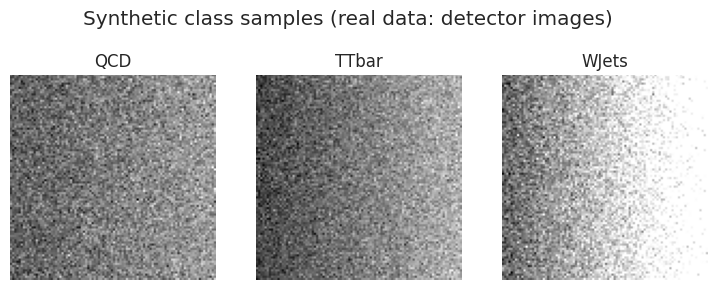

In [3]:
from projects.lhc_collision_classification.src.data_loader import load_dataset
from projects.lhc_collision_classification.src.preprocessing import (
    HogParams,
    build_feature_matrix,
    load_and_resize,
)

dataset = load_dataset(tmp_root)
print("Total images:", len(dataset))
print("Per-class:", dict(zip(dataset.class_names, dataset.class_sizes)))

fig, axes = plt.subplots(1, 3, figsize=(9, 3.2))
for ax, name in zip(axes, class_names):
    sample = io.imread(tmp_root / name / "img_000.png")
    ax.imshow(sample, cmap="gray")
    ax.set_title(name)
    ax.axis("off")
fig.suptitle("Synthetic class samples (real data: detector images)", y=1.02)
plt.show()

## 4. Extract HOG features

In [4]:
hog_params = HogParams(orientations=8, pixels_per_cell=(16, 16), cells_per_block=(2, 2))
X = build_feature_matrix(
    dataset.filepaths,
    image_size=(96, 96),
    hog_params=hog_params,
    log_every=0,
)
y = dataset.labels
print("Feature matrix:", X.shape)

Feature matrix: (180, 800)


## 5. Cross-validated model benchmark

We exclude `RBF SVM (PCA)` from this synthetic run because the
100-component PCA needs more samples than the toy dataset has. On
the full LHC data set (`with_pca=True` in the CLI) it runs cleanly.

In [5]:
from projects.lhc_collision_classification.src.evaluation import (
    best_model_by,
    evaluate_models,
    results_to_dataframe,
)
from projects.lhc_collision_classification.src.models import build_model_zoo

models = build_model_zoo(with_pca=False)
models.pop("RBF SVM (PCA)", None)  # see note above

results = evaluate_models(models, X, y, n_splits=3, random_state=42)
summary = results_to_dataframe(results)
summary

,accuracy,f1_macro,f1_weighted,balanced_accuracy
model,,,,
Random Forest,0.689 ± 0.021,0.688 ± 0.020,0.688 ± 0.020,0.689 ± 0.021
Linear SVM,0.644 ± 0.008,0.641 ± 0.008,0.641 ± 0.008,0.644 ± 0.008
Gradient Boosting,0.706 ± 0.034,0.704 ± 0.035,0.704 ± 0.035,0.706 ± 0.034
XGBoost,0.728 ± 0.016,0.729 ± 0.015,0.729 ± 0.015,0.728 ± 0.016


In [6]:
winner = best_model_by(results, metric="test_f1_macro")
print(f"Best model on synthetic data (macro-F1): {winner}")

Best model on synthetic data (macro-F1): XGBoost


## 6. Inspect the winner: confusion matrix and feature importances

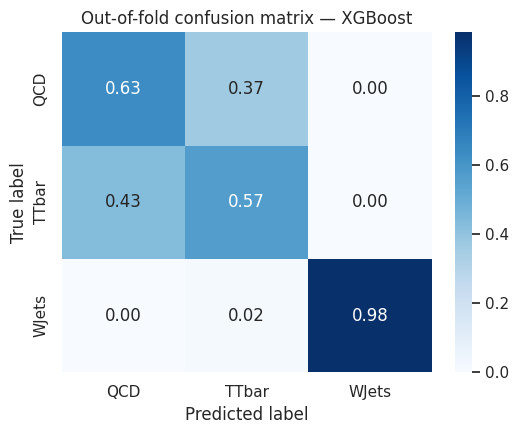

In [7]:
from utils.visualization import plot_confusion_matrix, plot_feature_importances

plot_confusion_matrix(
    y, results[winner].oof_predictions, class_names=list(class_names),
    title=f"Out-of-fold confusion matrix — {winner}",
)
plt.show()

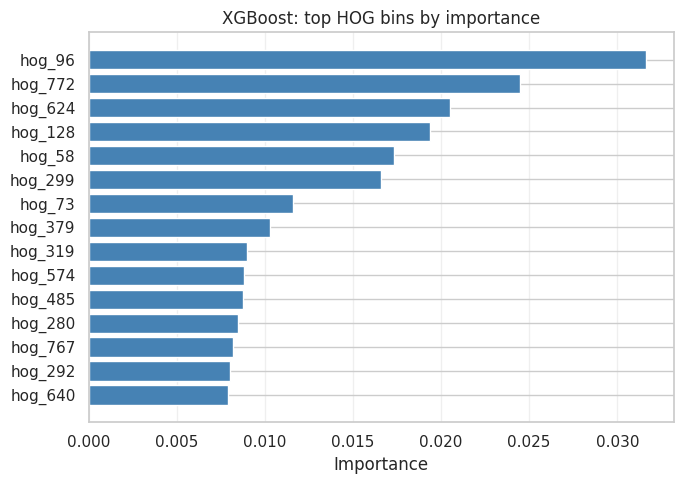

In [8]:
best_pipe = models[winner]
best_pipe.fit(X, y)
model_step = best_pipe.named_steps["model"]
if hasattr(model_step, "feature_importances_"):
    plot_feature_importances(
        np.asarray(model_step.feature_importances_),
        feature_names=[f"hog_{i}" for i in range(X.shape[1])],
        top_k=15,
        title=f"{winner}: top HOG bins by importance",
    )
    plt.show()
else:
    print(f"{winner} has no feature_importances_; skip.")

## 7. Running on the real dataset

Once you have downloaded the
[Proton Collision 13 TeV image set](https://www.kaggle.com/datasets/anilkumarpatibandla/proton-collision-image-set)
and unpacked it so that you have e.g. `~/data/proton/Train/{QCD,TTbar,WJets}`
and a matching `Test/`, run from the repo root:

```bash
python -m projects.lhc_collision_classification.src.train \
    --train-dir ~/data/proton/Train \
    --test-dir  ~/data/proton/Test \
    --image-size 256 \
    --with-pca
```

The CLI prints the same cross-validated metrics table this notebook
displays, scaled up to the full ~30k-image dataset.

In [9]:
shutil.rmtree(tmp_root)
print("Cleaned up synthetic dataset at", tmp_root)

Cleaned up synthetic dataset at /tmp/lhc_synth_3n1rcwdn
